# Cross-Sell Acceptance Prediction

**Data Science Internship Assessment — Chronoanalytics / Advanto**

**Objective:** Build a machine learning model to predict whether a customer will accept a cross-selling offer, and derive actionable business insights.

**Dataset:** 152 customers × 19 features 

## Import Libraries

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Display settings
pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid')

## Load the Dataset

In [3]:
df = pd.read_csv("customer_dataset.csv")

## Understand the Dataset

In [4]:
# Display first 5 rows
df.head()

,Customer_ID,Age,Gender,City,Annual_Income,Customer_Segment,Existing_Product,Product_Category,Purchase_Amount,Purchase_Frequency,Last_Purchase_Days,Avg_Order_Value,Total_Orders,Discount_Used,Preferred_Channel,Customer_Tenure,Support_Calls,Satisfaction_Score,Cross_Sell_Accepted
0,C0001,23,Female,Pune,1186213.0,Gold,Credit Card,Banking,391123,24,280,200000,44,Yes,Online,1,4.0,2.0,Yes
1,C0002,46,Female,Ahmedabad,1083985.0,Silver,Insurance,Insurance,345726,20,113,69145,27,Yes,Online,9,NaN,5.0,Yes
2,C0003,34,Male,Pune,639004.0,Silver,Home Loan,Loans,55707,7,310,18569,23,No,Mobile App,3,5.0,1.0,No
3,C0004,32,Female,Pune,1766807.0,Platinum,Car Loan,Loans,105814,3,339,105814,3,Yes,Online,7,8.0,3.0,No
4,C0005,59,Male,Bengaluru,1802651.0,Silver,Personal Loan,Loans,114842,21,350,38280,45,Yes,Mobile App,8,5.0,2.0,Yes


In [5]:
# Number of rows and columns
df.shape

(152, 19)

In [6]:
# Information about dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          152 non-null    str    
 1   Age                  152 non-null    int64  
 2   Gender               152 non-null    str    
 3   City                 152 non-null    str    
 4   Annual_Income        146 non-null    float64
 5   Customer_Segment     152 non-null    str    
 6   Existing_Product     152 non-null    str    
 7   Product_Category     152 non-null    str    
 8   Purchase_Amount      152 non-null    int64  
 9   Purchase_Frequency   152 non-null    int64  
 10  Last_Purchase_Days   152 non-null    int64  
 11  Avg_Order_Value      152 non-null    int64  
 12  Total_Orders         152 non-null    int64  
 13  Discount_Used        152 non-null    str    
 14  Preferred_Channel    152 non-null    str    
 15  Customer_Tenure      152 non-null    int64  
 16  S

In [7]:
# Statistical summary of numerical columns
df.describe()

,Age,Annual_Income,Purchase_Amount,Purchase_Frequency,Last_Purchase_Days,Avg_Order_Value,Total_Orders,Customer_Tenure,Support_Calls,Satisfaction_Score
count,152.000000,1.460000e+02,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,146.000000,147.000000
mean,40.947368,1.365417e+06,233241.032895,16.315789,190.973684,88343.881579,26.500000,8.513158,4.712329,3.142857
std,13.817538,6.377824e+05,145815.702304,8.258587,103.224756,63724.561232,14.580673,3.841197,2.954736,1.428669
min,18.000000,2.618930e+05,7753.000000,1.000000,10.000000,2263.000000,1.000000,1.000000,0.000000,1.000000
25%,29.000000,8.432915e+05,106144.750000,9.000000,113.000000,33017.500000,13.000000,6.000000,2.000000,2.000000
50%,40.500000,1.314410e+06,222184.000000,17.000000,183.000000,80459.500000,27.000000,8.000000,5.000000,3.000000
75%,53.250000,1.919063e+06,356751.250000,23.000000,287.250000,129393.250000,39.000000,12.000000,7.000000,4.000000
max,65.000000,2.490276e+06,498667.000000,30.000000,364.000000,200000.000000,50.000000,15.000000,10.000000,5.000000


## Data Cleaning & Preprocessing

In [8]:
# Check Missing values
missing_values = df.isnull().sum()
print(missing_values)

Customer_ID            0
Age                    0
Gender                 0
City                   0
Annual_Income          6
Customer_Segment       0
Existing_Product       0
Product_Category       0
Purchase_Amount        0
Purchase_Frequency     0
Last_Purchase_Days     0
Avg_Order_Value        0
Total_Orders           0
Discount_Used          0
Preferred_Channel      0
Customer_Tenure        0
Support_Calls          6
Satisfaction_Score     5
Cross_Sell_Accepted    0
dtype: int64


In [9]:
print(missing_values[missing_values > 0].sort_values(ascending=False))

Annual_Income         6
Support_Calls         6
Satisfaction_Score    5
dtype: int64


In [10]:
for col in ['Annual_Income', 'Support_Calls', 'Satisfaction_Score']:
    df[col] = df[col].fillna(df[col].median())

In [11]:
# Check Missing values Again
df.isnull().sum()

Customer_ID            0
Age                    0
Gender                 0
City                   0
Annual_Income          0
Customer_Segment       0
Existing_Product       0
Product_Category       0
Purchase_Amount        0
Purchase_Frequency     0
Last_Purchase_Days     0
Avg_Order_Value        0
Total_Orders           0
Discount_Used          0
Preferred_Channel      0
Customer_Tenure        0
Support_Calls          0
Satisfaction_Score     0
Cross_Sell_Accepted    0
dtype: int64

In [12]:
# Duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 2


In [13]:
df = df.drop_duplicates()

In [14]:
# Target Variable
df["Cross_Sell_Accepted"].value_counts()

Cross_Sell_Accepted
Yes    90
No     60
Name: count, dtype: int64

In [15]:
Cross_Sell_Accepted_rate = df['Cross_Sell_Accepted'].value_counts(normalize=True)['Yes'] * 100
print(f'Overall Cross Sell Accepted Rate: {Cross_Sell_Accepted_rate:.2f}%')

Overall Cross Sell Accepted Rate: 60.00%


In [16]:
# Separate Numerical and Categorical Columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numerical Columns")
print(numerical_columns)

print("\nCategorical Columns")
print(categorical_columns)

Numerical Columns
Index(['Age', 'Annual_Income', 'Purchase_Amount', 'Purchase_Frequency',
       'Last_Purchase_Days', 'Avg_Order_Value', 'Total_Orders',
       'Customer_Tenure', 'Support_Calls', 'Satisfaction_Score'],
      dtype='str')

Categorical Columns
Index(['Customer_ID', 'Gender', 'City', 'Customer_Segment', 'Existing_Product',
       'Product_Category', 'Discount_Used', 'Preferred_Channel',
       'Cross_Sell_Accepted'],
      dtype='str')


In [17]:
# Save cleaned dataset
df.to_csv("Customer_dataset_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [18]:
# Drop customerID
df = df.drop('Customer_ID', axis=1)

## Exploratory Data Analysis (EDA)

### 1. Target Variable Distribution

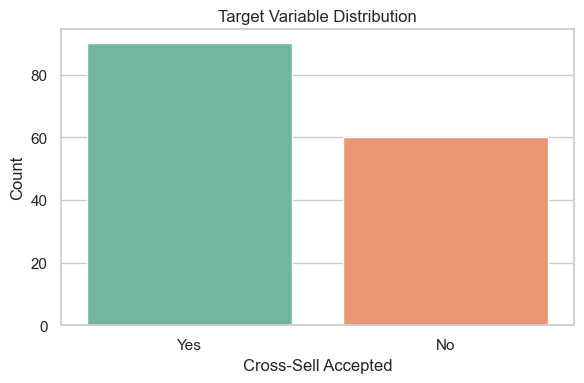

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Cross_Sell_Accepted",
    palette="Set2"
)

plt.title("Target Variable Distribution")
plt.xlabel("Cross-Sell Accepted")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### 2. Satisfaction Score vs Cross-Sell Acceptance

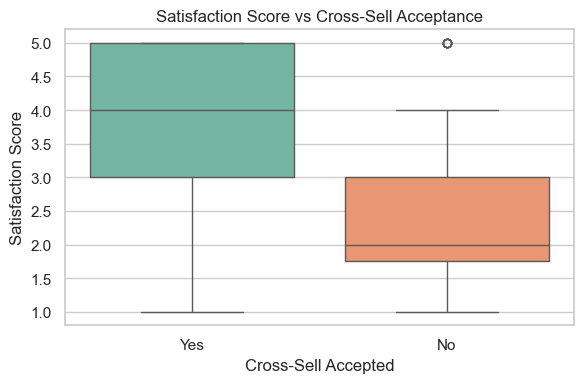

In [20]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Cross_Sell_Accepted",
    y="Satisfaction_Score",
    palette="Set2"
)

plt.title("Satisfaction Score vs Cross-Sell Acceptance")
plt.xlabel("Cross-Sell Accepted")
plt.ylabel("Satisfaction Score")

plt.tight_layout()
plt.show()

### 3. Customer Segment vs Cross-Sell

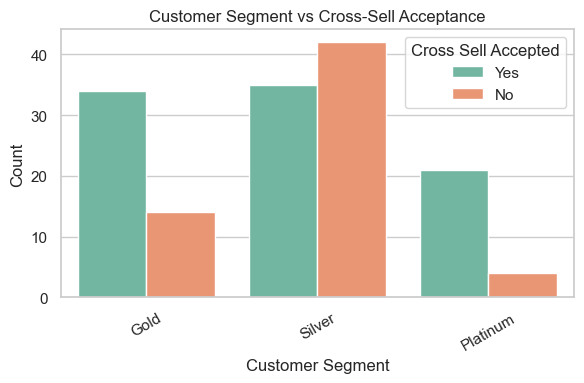

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Customer_Segment",
    hue="Cross_Sell_Accepted",
    palette="Set2"
)

plt.title("Customer Segment vs Cross-Sell Acceptance")
plt.xlabel("Customer Segment")
plt.ylabel("Count")

plt.xticks(rotation=30)

plt.legend(title="Cross Sell Accepted")

plt.tight_layout()
plt.show()

### 4. Existing Product vs Cross-Sell

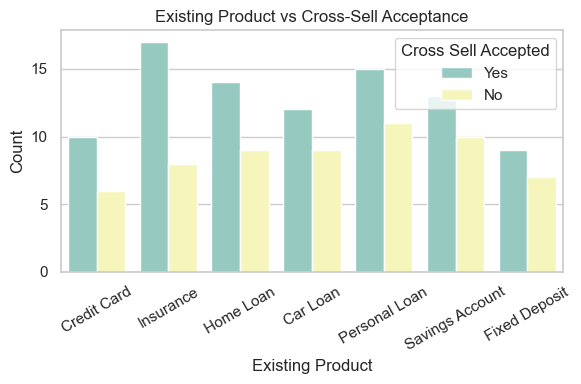

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Existing_Product",
    hue="Cross_Sell_Accepted",
    palette="Set3"
)

plt.title("Existing Product vs Cross-Sell Acceptance")
plt.xlabel("Existing Product")
plt.ylabel("Count")

plt.xticks(rotation=30)

plt.legend(title="Cross Sell Accepted")

plt.tight_layout()
plt.show()

### 5. Purchase Frequency vs Cross-Sell

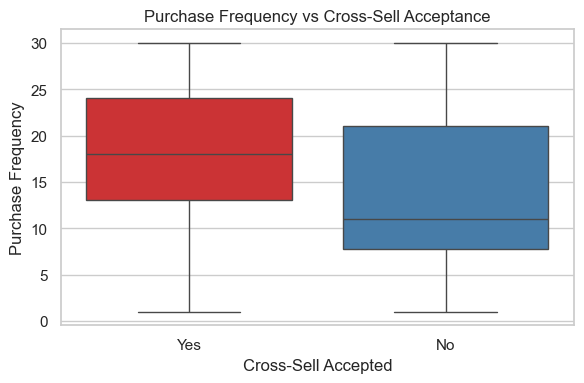

In [23]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Cross_Sell_Accepted",
    y="Purchase_Frequency",
    palette="Set1"
)

plt.title("Purchase Frequency vs Cross-Sell Acceptance")
plt.xlabel("Cross-Sell Accepted")
plt.ylabel("Purchase Frequency")

plt.tight_layout()
plt.show()

### 6. Preferred Channel vs Cross-Sell

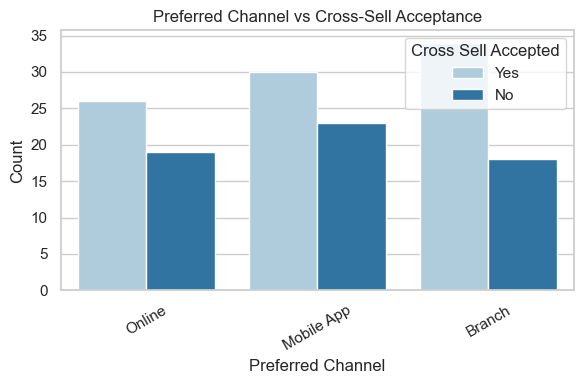

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Preferred_Channel",
    hue="Cross_Sell_Accepted",
    palette="Paired"
)

plt.title("Preferred Channel vs Cross-Sell Acceptance")
plt.xlabel("Preferred Channel")
plt.ylabel("Count")

plt.xticks(rotation=30)

plt.legend(title="Cross Sell Accepted")

plt.tight_layout()
plt.show()

### 7. Customer Tenure vs Cross-Sell

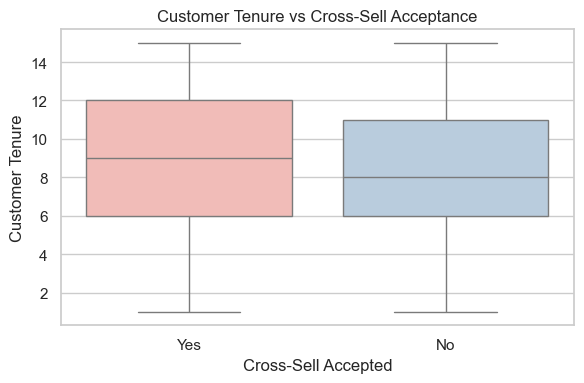

In [25]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Cross_Sell_Accepted",
    y="Customer_Tenure",
    palette="Pastel1"
)

plt.title("Customer Tenure vs Cross-Sell Acceptance")
plt.xlabel("Cross-Sell Accepted")
plt.ylabel("Customer Tenure")

plt.tight_layout()
plt.show()

### 8. Correlation Heatmap

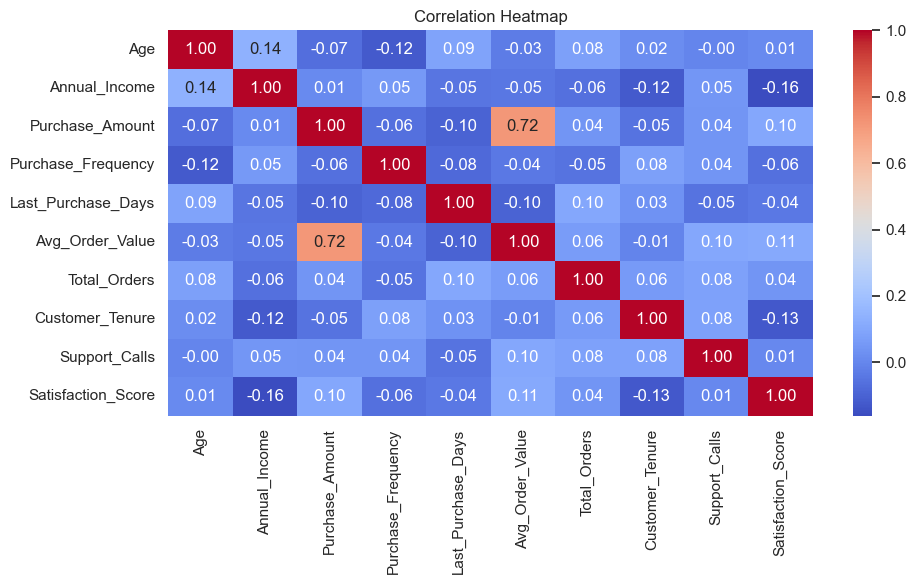

In [26]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

## Feature Engineering

In [27]:
# Engineered features
df['Avg_Spend_Per_Order'] = df['Purchase_Amount'] / df['Total_Orders'].replace(0, 1)

df['Recency_Score'] = pd.cut(df['Last_Purchase_Days'],
                              bins=[-1, 30, 90, 180, 1000],
                              labels=[4, 3, 2, 1]).astype(int)  # higher = more recent

df['Tenure_Group'] = pd.cut(df['Customer_Tenure'],
                             bins=[-1, 12, 36, 1000],
                             labels=['New', 'Mid', 'Loyal'])

df[['Avg_Spend_Per_Order', 'Recency_Score', 'Tenure_Group']].head()


,Avg_Spend_Per_Order,Recency_Score,Tenure_Group
0,8889.159091,1,New
1,12804.666667,2,New
2,2422.043478,1,New
3,35271.333333,1,New
4,2552.044444,1,New


## Encode Target Variable

In [28]:
# Label Encoding 
cat_features = ['Gender', 'City', 'Customer_Segment', 'Existing_Product',
               'Product_Category', 'Discount_Used', 'Preferred_Channel',
               'Cross_Sell_Accepted', 'Tenure_Group']

encoders = {}
for col in cat_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

df.head()

,Age,Gender,City,Annual_Income,Customer_Segment,Existing_Product,Product_Category,Purchase_Amount,Purchase_Frequency,Last_Purchase_Days,Avg_Order_Value,Total_Orders,Discount_Used,Preferred_Channel,Customer_Tenure,Support_Calls,Satisfaction_Score,Cross_Sell_Accepted,Avg_Spend_Per_Order,Recency_Score,Tenure_Group
0,23,0,9,1186213.0,0,1,0,391123,24,280,200000,44,1,2,1,4.0,2.0,1,8889.159091,1,1
1,46,0,0,1083985.0,2,4,1,345726,20,113,69145,27,1,2,9,5.0,5.0,1,12804.666667,2,1
2,34,1,9,639004.0,2,3,3,55707,7,310,18569,23,0,1,3,5.0,1.0,0,2422.043478,1,1
3,32,0,9,1766807.0,1,0,3,105814,3,339,105814,3,1,2,7,8.0,3.0,0,35271.333333,1,1
4,59,1,1,1802651.0,2,5,3,114842,21,350,38280,45,1,1,8,5.0,2.0,1,2552.044444,1,1


## Train-Test Split

In [29]:
X = df.drop('Cross_Sell_Accepted', axis=1)

y = df['Cross_Sell_Accepted']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [31]:
# Scaling for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled  = scaler.transform(X_test)

## Model 1: Logistic Regression

In [32]:
# Train Logistic Regression on scaled data
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_lr = lr.predict(X_test_scaled)

# Compute all four key metrics
acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)

print('Logistic Regression Results:')
print(f'Accuracy : {acc_lr:.4f}')
print(f'Precision: {prec_lr:.4f}')
print(f'Recall   : {rec_lr:.4f}')
print(f'F1-Score : {f1_lr:.4f}')

Logistic Regression Results:
Accuracy : 0.7667
Precision: 0.7391
Recall   : 0.9444
F1-Score : 0.8293


In [33]:
#Classification Report
print(classification_report(y_test,y_pred_lr,target_names=['No Cross-Sell', 'Cross-Sell']))

               precision    recall  f1-score   support

No Cross-Sell       0.86      0.50      0.63        12
   Cross-Sell       0.74      0.94      0.83        18

     accuracy                           0.77        30
    macro avg       0.80      0.72      0.73        30
 weighted avg       0.79      0.77      0.75        30



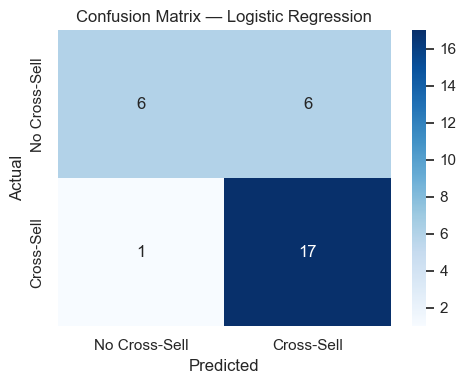

In [34]:
# Confusion Matrix — Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Cross-Sell', 'Cross-Sell'],
    yticklabels=['No Cross-Sell', 'Cross-Sell']
)

plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Model 2: Random Forest Classifier

In [35]:
# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)  # Tree models do not require feature scaling

# Predict on test set
y_pred_rf = rf.predict(X_test)

# Compute all four key metrics
acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)

print('Random Forest Results:')
print(f'Accuracy : {acc_rf:.4f}')
print(f'Precision: {prec_rf:.4f}')
print(f'Recall   : {rec_rf:.4f}')
print(f'F1-Score : {f1_rf:.4f}')

Random Forest Results:
Accuracy : 0.8333
Precision: 0.7826
Recall   : 1.0000
F1-Score : 0.8780


In [36]:
#Classification Report
print(classification_report(y_test,y_pred_rf,target_names=['No Cross-Sell', 'Cross-Sell']))

               precision    recall  f1-score   support

No Cross-Sell       1.00      0.58      0.74        12
   Cross-Sell       0.78      1.00      0.88        18

     accuracy                           0.83        30
    macro avg       0.89      0.79      0.81        30
 weighted avg       0.87      0.83      0.82        30



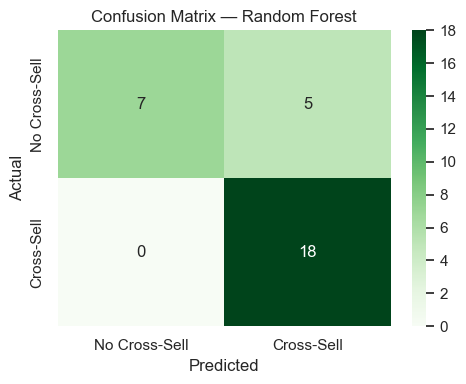

In [37]:
# Confusion Matrix — Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Cross-Sell', 'Cross-Sell'],
    yticklabels=['No Cross-Sell', 'Cross-Sell']
)

plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Model Comparison

In [38]:
# Side-by-side comparison table — all values computed from actual model outputs
comparison = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Random Forest'],
    'Accuracy' : [round(acc_lr, 4),  round(acc_rf, 4)],
    'Precision': [round(prec_lr, 4), round(prec_rf, 4)],
    'Recall'   : [round(rec_lr, 4),  round(rec_rf, 4)],
    'F1-Score' : [round(f1_lr, 4),   round(f1_rf, 4)]
})

comparison.set_index('Model', inplace=True)
comparison

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.7667,0.7391,0.9444,0.8293
Random Forest,0.8333,0.7826,1.0000,0.8780


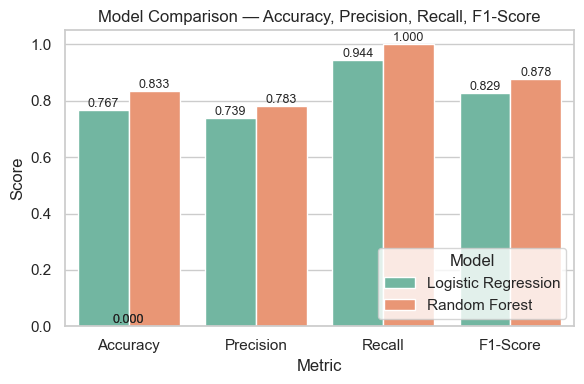

In [39]:
# Visual comparison — grouped bar chart
comp_melted = comparison.reset_index().melt(
    id_vars='Model', var_name='Metric', value_name='Score'
)

plt.figure(figsize=(6,4))
ax = sns.barplot(data=comp_melted, x='Metric', y='Score',
                 hue='Model', palette='Set2')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Model Comparison — Accuracy, Precision, Recall, F1-Score')
plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.legend(title='Model')
plt.tight_layout(); plt.show()


## ROC-AUC Score for both models

In [40]:
from sklearn.metrics import roc_auc_score, roc_curve

# ROC-AUC Scores
auc_lr = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

print(f"Logistic Regression ROC-AUC : {auc_lr:.4f}")
print(f"Random Forest      ROC-AUC : {auc_rf:.4f}")

Logistic Regression ROC-AUC : 0.8148
Random Forest      ROC-AUC : 0.9907


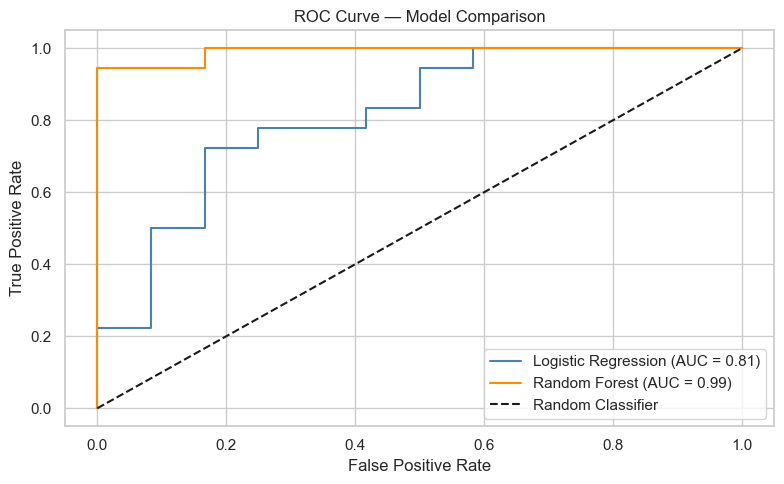

In [41]:
# ROC Curve — both models on one chart
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test_scaled)[:, 1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test)[:, 1])

plt.figure(figsize=(8, 5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})', color='steelblue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison') 
plt.legend()
plt.tight_layout()
plt.show()

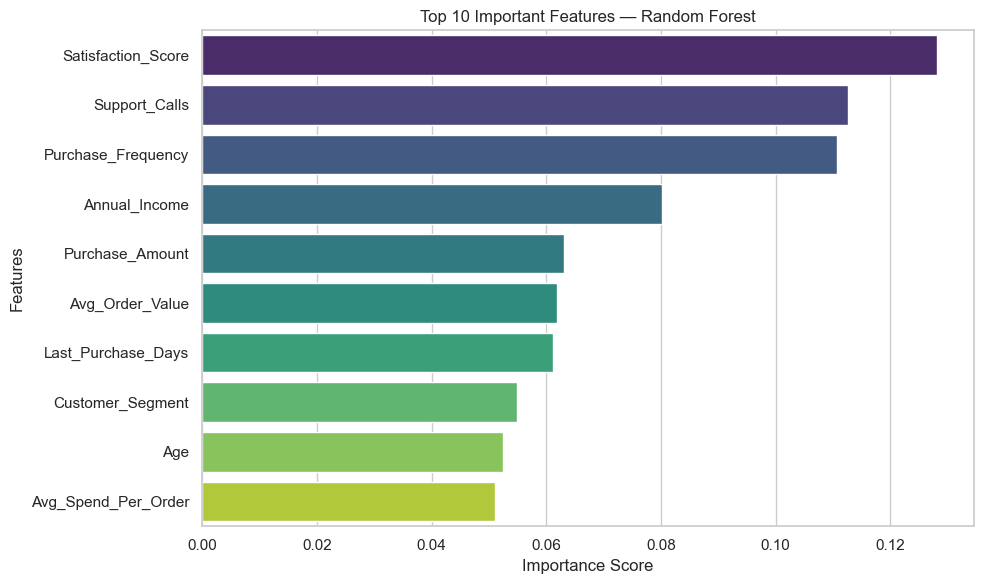

In [42]:
plt.figure(figsize=(10, 6))

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 10 Important Features — Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

## Business Insights

1. Customers with higher purchase frequency are more likely to accept cross-sell offers, indicating strong engagement drives conversion.

2. Long-tenure customers show higher acceptance, reflecting increased trust and loyalty over time.

3. Higher satisfaction scores positively influence cross-sell acceptance, making customer experience a key driver.

4. Customers using discounts are more responsive to cross-sell campaigns, showing price sensitivity.

5. Preferred communication channels significantly impact acceptance rates, highlighting the importance of targeted marketing strategies.

6. High-value customers contribute the most to cross-selling success and should be prioritized.

7. Existing product ownership influences interest in additional products, enabling effective bundling strategies.

8. Customer segmentation helps identify distinct behavior patterns for targeted marketing.

## Recommendations

1. Focus cross-selling campaigns on high-value and frequent customers to maximize ROI.

2. Use personalized recommendations based on purchase history and existing products.

3. Improve customer satisfaction before launching cross-sell campaigns.

4. Provide targeted discount offers for medium-value or hesitant customers.

5. Use preferred communication channels for marketing campaigns.

6. Apply segment-based targeting strategies (Silver, Gold, Platinum).

7. Promote bundled product offerings to increase acceptance rates.

8. Continuously monitor customer behavior using the trained ML model.

9. Deploy the Random Forest model in production if it performs better than Logistic Regression.

## Power BI Dashboard

![Dashboard](dashboard.png)